In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os



In [2]:
sys.path.append(os.path.abspath(".."))

In [3]:
from src.data_utils import (load_data)
from src.eda_utils import (
    data_structure,
    data_types,
    show_full_dataframe,
    full_summary,
    data_quality_report,
    check_numerical_anomalies,
    check_categorical_anomalies,
    check_placeholder_values,
    plot_numeric_distributions,
    plot_categorical_counts,
    plot_target_distribution,
    plot_feature_vs_target,
    outlier_overview
)

# BEFORE CLEANING

In [4]:
X_train = load_data("../data/X_train.csv")
y_train = load_data("../data/y_train.csv")

df_raw = X_train.merge(y_train, on="id")

DataFrame successfully loaded.
Shape: (59400, 40)
DataFrame successfully loaded.
Shape: (59400, 2)


In [5]:
data_structure(df_raw)

 Shape: (59400, 41)

 Columns:
['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer', 'longitude', 'latitude', 'wpt_name', 'num_private', 'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga', 'ward', 'population', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'construction_year', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group', 'status_group']


In [7]:
data_types(df_raw)

 Data Types:
id                         int64
amount_tsh               float64
date_recorded                str
funder                       str
gps_height                 int64
installer                    str
longitude                float64
latitude                 float64
wpt_name                     str
num_private                int64
basin                        str
subvillage                   str
region                       str
region_code                int64
district_code              int64
lga                          str
ward                         str
population                 int64
public_meeting            object
recorded_by                  str
scheme_management            str
scheme_name                  str
permit                    object
construction_year          int64
extraction_type              str
extraction_type_group        str
extraction_type_class        str
management                   str
management_group             str
payment                      s

In [8]:
show_full_dataframe(df_raw)

      id  amount_tsh date_recorded        funder  gps_height     installer  longitude   latitude              wpt_name  num_private                    basin  subvillage   region  region_code  \
0  69572      6000.0    2011-03-14         Roman        1390         Roman  34.938093  -9.856322                  none            0               Lake Nyasa    Mnyusi B   Iringa           11   
1   8776         0.0    2013-03-06       Grumeti        1399       GRUMETI  34.698766  -2.147466              Zahanati            0            Lake Victoria     Nyamara     Mara           20   
2  34310        25.0    2013-02-25  Lottery Club         686  World vision  37.460664  -3.821329           Kwa Mahundi            0                  Pangani     Majengo  Manyara           21   
3  67743         0.0    2013-01-28        Unicef         263        UNICEF  38.486161 -11.155298  Zahanati Ya Nanyumbu            0  Ruvuma / Southern Coast  Mahakamani   Mtwara           90   
4  19728         0.0    2011-0

In [9]:
full_summary(df_raw)


Numeric Summary:
                 id     amount_tsh    gps_height     longitude      latitude  \
count  59400.000000   59400.000000  59400.000000  59400.000000  5.940000e+04   
mean   37115.131768     317.650385    668.297239     34.077427 -5.706033e+00   
std    21453.128371    2997.574558    693.116350      6.567432  2.946019e+00   
min        0.000000       0.000000    -90.000000      0.000000 -1.164944e+01   
25%    18519.750000       0.000000      0.000000     33.090347 -8.540621e+00   
50%    37061.500000       0.000000    369.000000     34.908743 -5.021597e+00   
75%    55656.500000      20.000000   1319.250000     37.178387 -3.326156e+00   
max    74247.000000  350000.000000   2770.000000     40.345193 -2.000000e-08   

        num_private   region_code  district_code    population  \
count  59400.000000  59400.000000   59400.000000  59400.000000   
mean       0.474141     15.297003       5.629747    179.909983   
std       12.236230     17.587406       9.633649    471.482176  

In [10]:
data_quality_report(df_raw)


 Missing Values Report:
                       missing_values  percentage
scheme_name                     28810   48.501684
scheme_management                3878    6.528620
installer                        3655    6.153199
funder                           3637    6.122896
public_meeting                   3334    5.612795
permit                           3056    5.144781
subvillage                        371    0.624579
wpt_name                            2    0.003367
id                                  0    0.000000
latitude                            0    0.000000
longitude                           0    0.000000
date_recorded                       0    0.000000
gps_height                          0    0.000000
amount_tsh                          0    0.000000
num_private                         0    0.000000
basin                               0    0.000000
region                              0    0.000000
ward                                0    0.000000
lga                       

In [11]:
check_numerical_anomalies(df_raw)

 Numerical Anomalies:
{}


{}

In [12]:
check_categorical_anomalies(df_raw)

 Categorical Anomalies (with counts):
{'funder': {'0': 777}, 'installer': {'0': 777}, 'wpt_name': {'24': 1}, 'subvillage': {'1': 132, '19': 3, '44': 3, '54': 2, '45': 1, '63': 1, '18': 1, '62': 1, '60': 1, '49': 1, '43': 1, '20': 1, '42': 1, '48': 1, '47': 1, '30': 1, '24': 1}}


{'funder': {'0': 777},
 'installer': {'0': 777},
 'wpt_name': {'24': 1},
 'subvillage': {'1': 132,
  '19': 3,
  '44': 3,
  '54': 2,
  '45': 1,
  '63': 1,
  '18': 1,
  '62': 1,
  '60': 1,
  '49': 1,
  '43': 1,
  '20': 1,
  '42': 1,
  '48': 1,
  '47': 1,
  '30': 1,
  '24': 1}}

In [13]:
check_placeholder_values(df_raw)

 Placeholder Values Found:
{'funder': {'0': 777, 'Unknown': 4}, 'installer': {'0': 777, 'Unknown': 3, 'unknown': 1}, 'wpt_name': {'none': 3563, 'Unknown': 3}, 'scheme_name': {'none': 25}, 'management': {'unknown': 561}, 'management_group': {'unknown': 561}, 'payment': {'unknown': 8157}, 'payment_type': {'unknown': 8157}, 'water_quality': {'unknown': 1876}, 'quality_group': {'unknown': 1876}, 'quantity': {'unknown': 789}, 'quantity_group': {'unknown': 789}, 'source': {'unknown': 66}, 'source_class': {'unknown': 278}}


{'funder': {'0': 777, 'Unknown': 4},
 'installer': {'0': 777, 'Unknown': 3, 'unknown': 1},
 'wpt_name': {'none': 3563, 'Unknown': 3},
 'scheme_name': {'none': 25},
 'management': {'unknown': 561},
 'management_group': {'unknown': 561},
 'payment': {'unknown': 8157},
 'payment_type': {'unknown': 8157},
 'water_quality': {'unknown': 1876},
 'quality_group': {'unknown': 1876},
 'quantity': {'unknown': 789},
 'quantity_group': {'unknown': 789},
 'source': {'unknown': 66},
 'source_class': {'unknown': 278}}

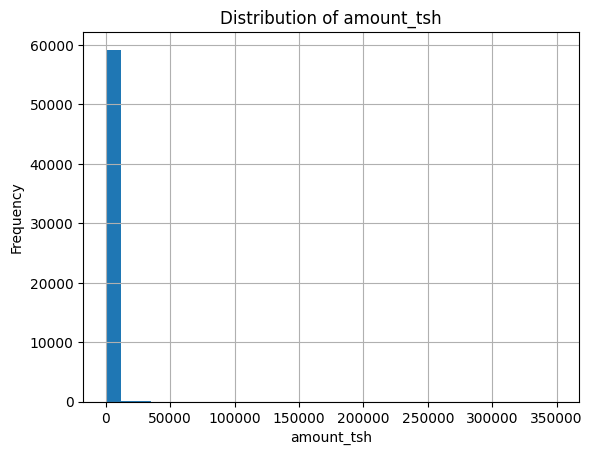

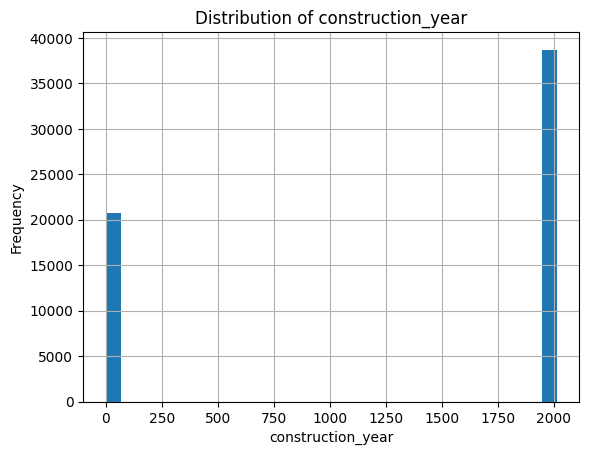

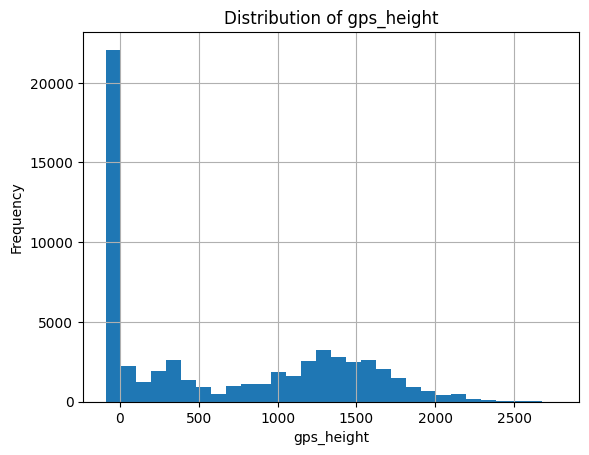

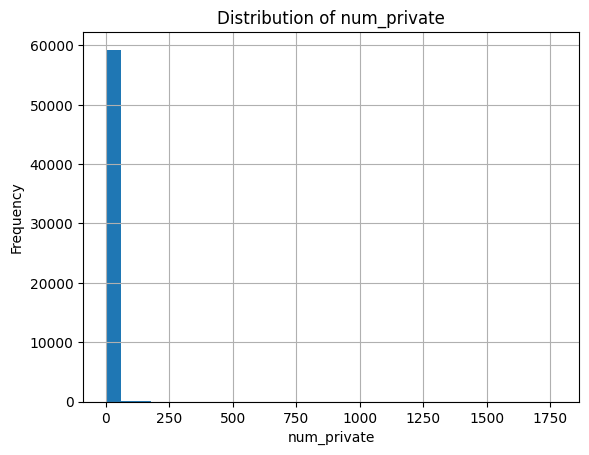

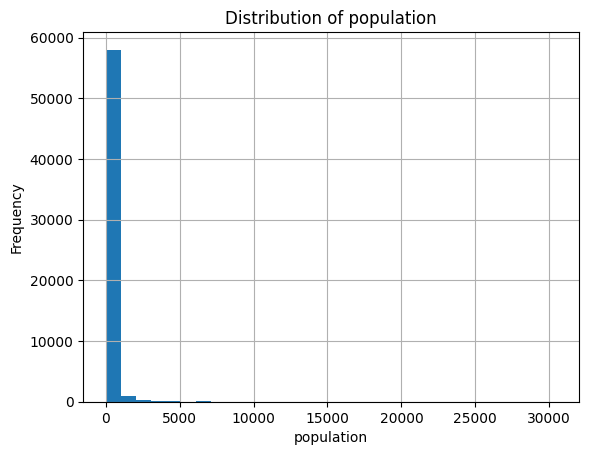

In [14]:
plot_numeric_distributions(df_raw)


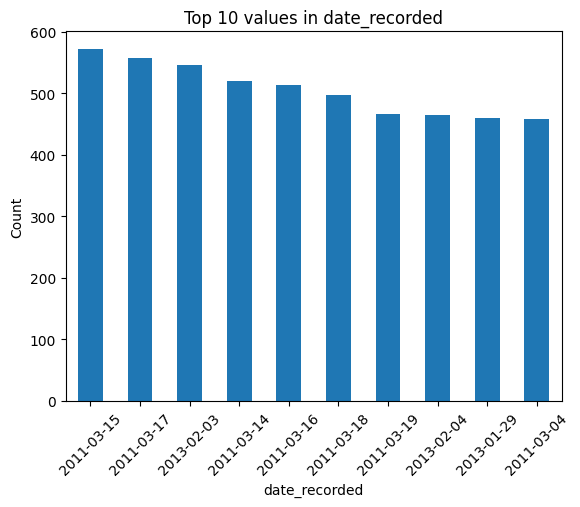

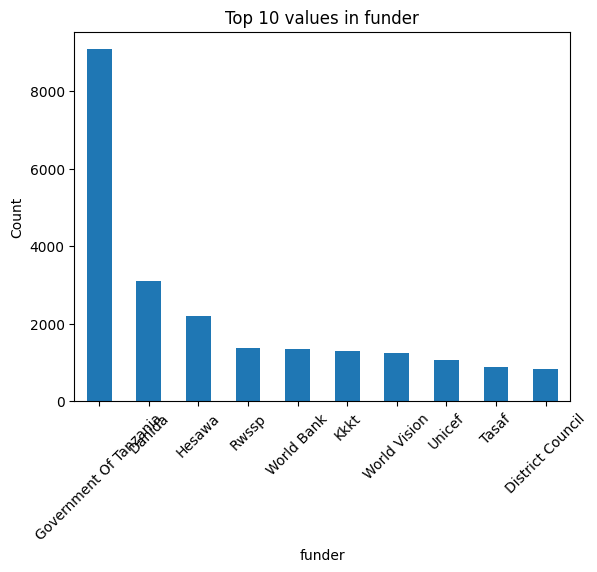

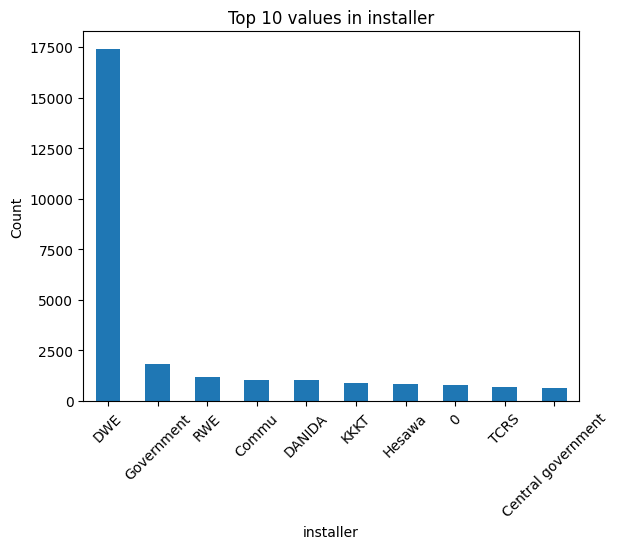

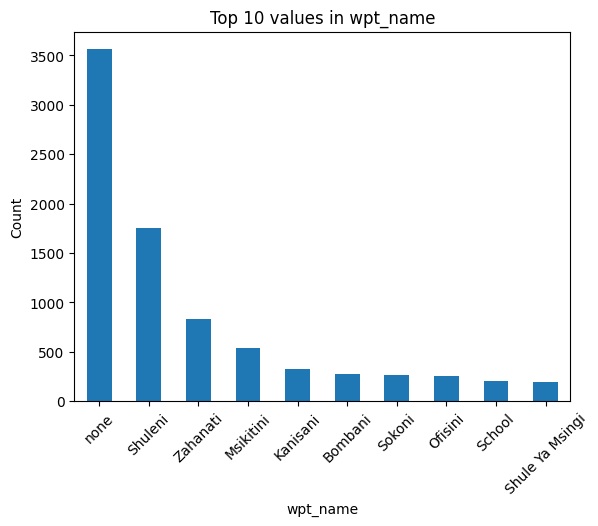

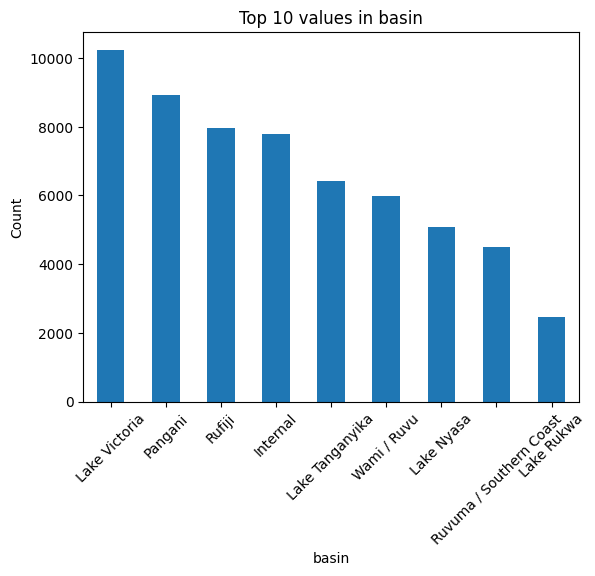

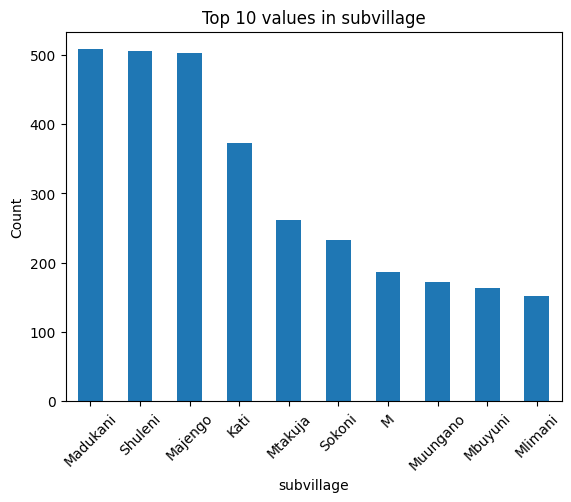

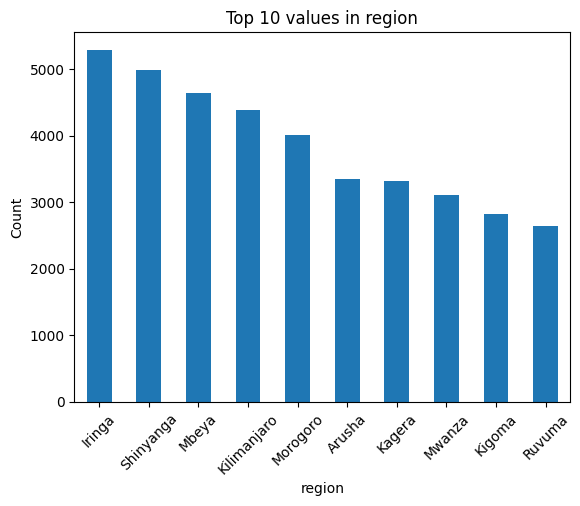

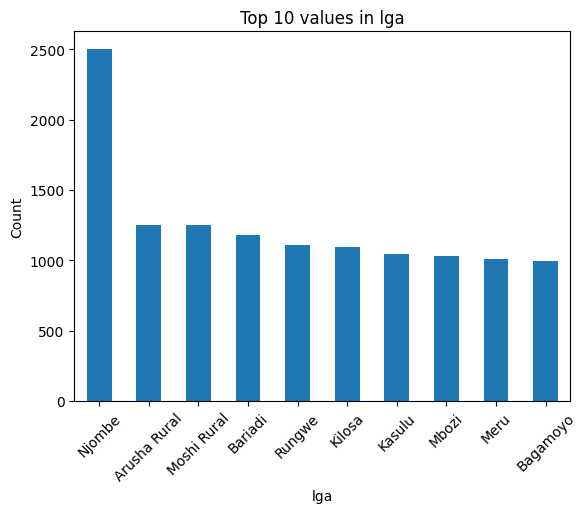

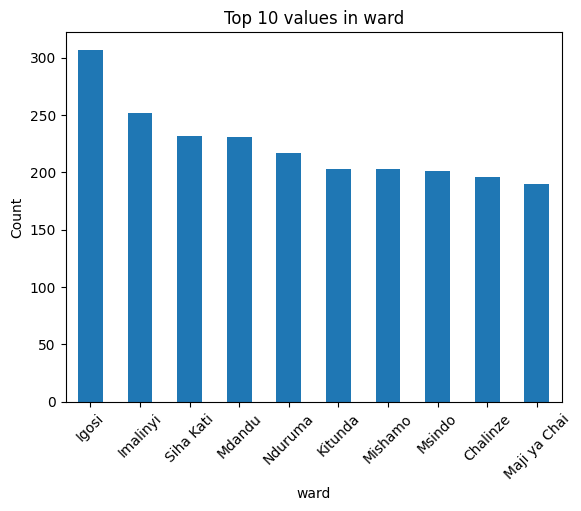

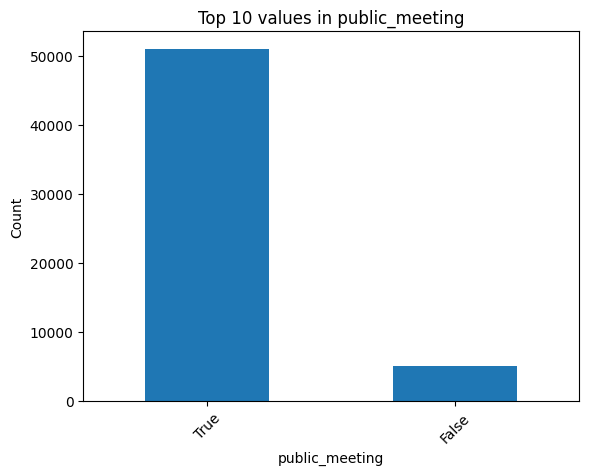

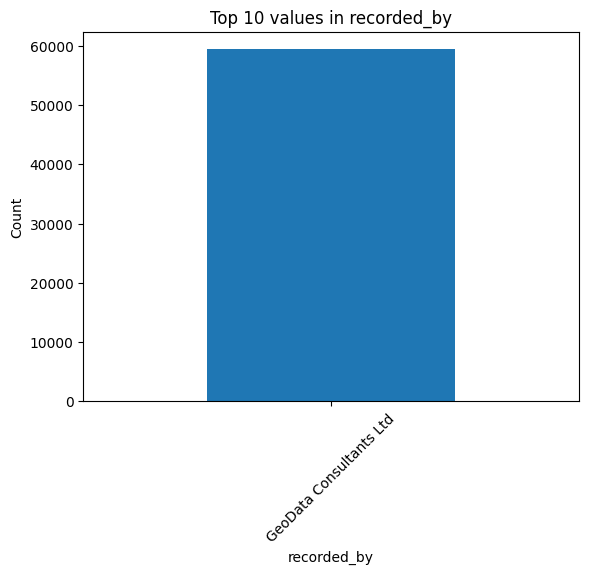

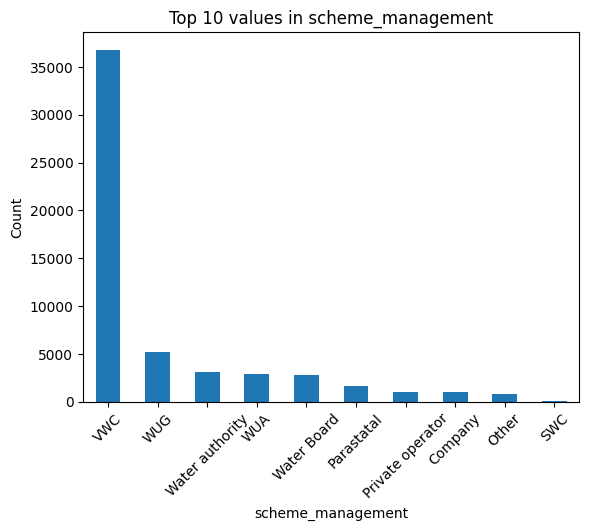

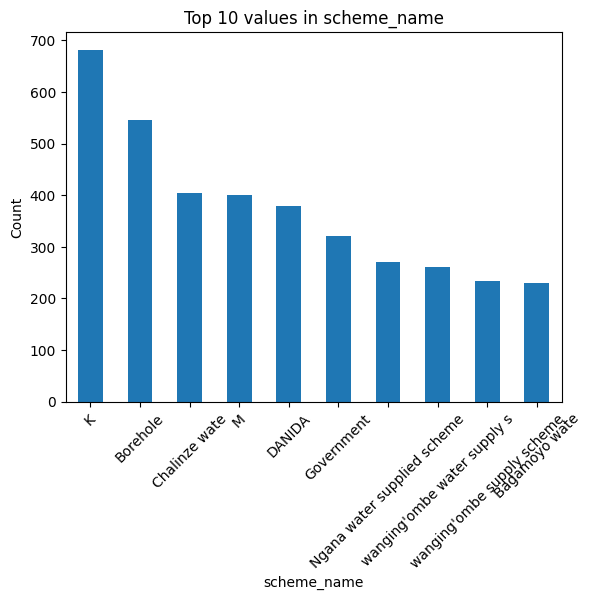

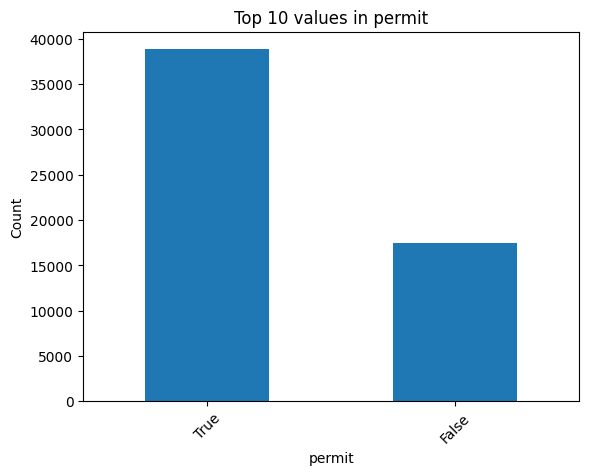

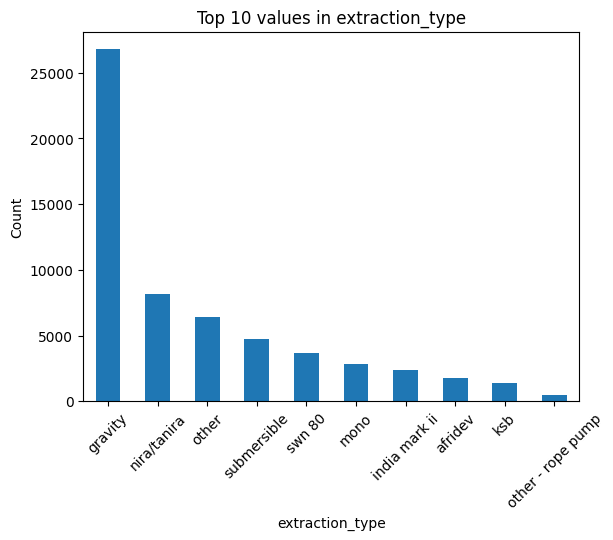

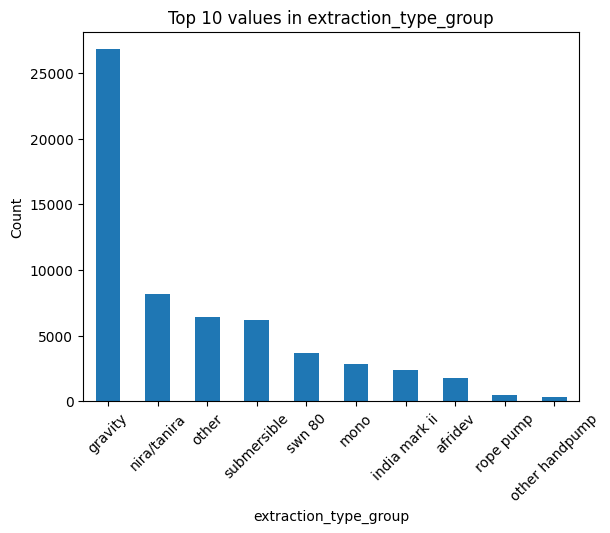

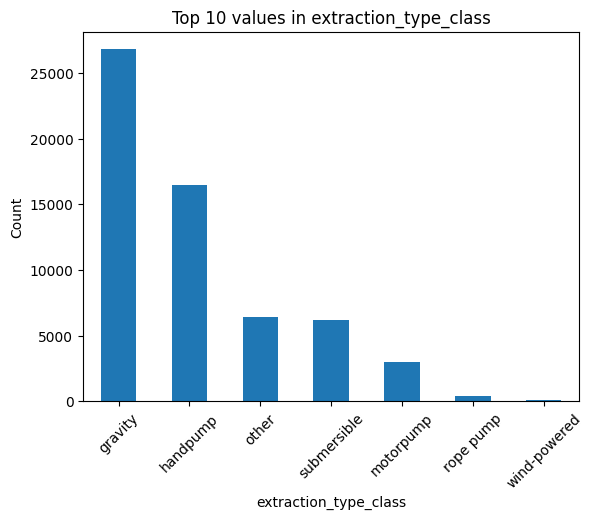

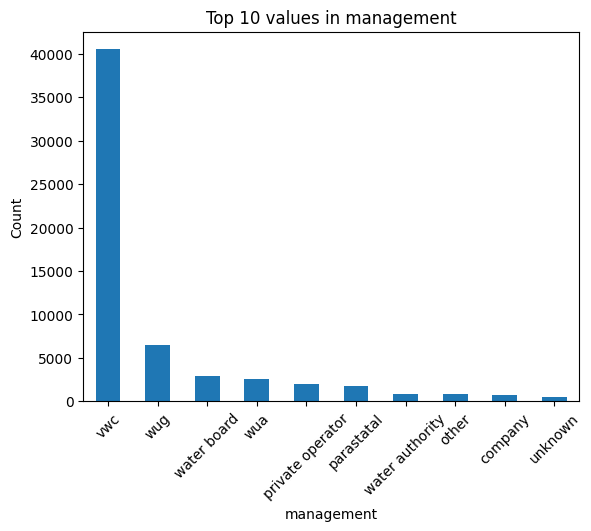

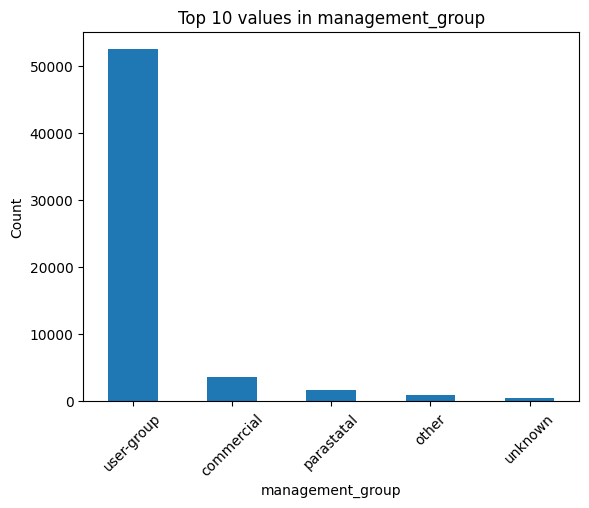

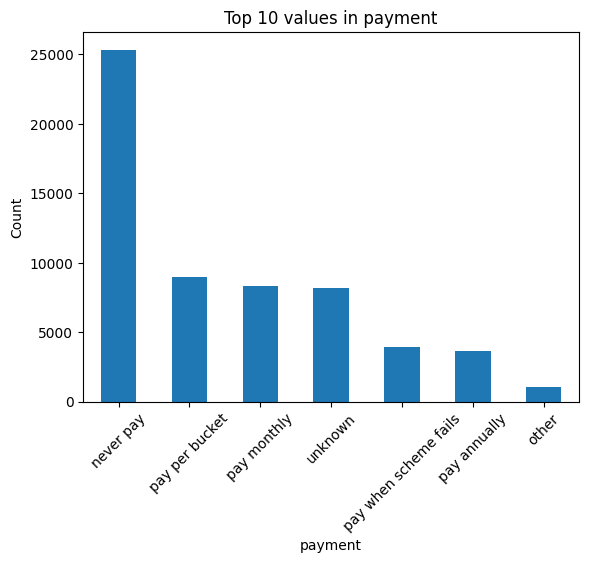

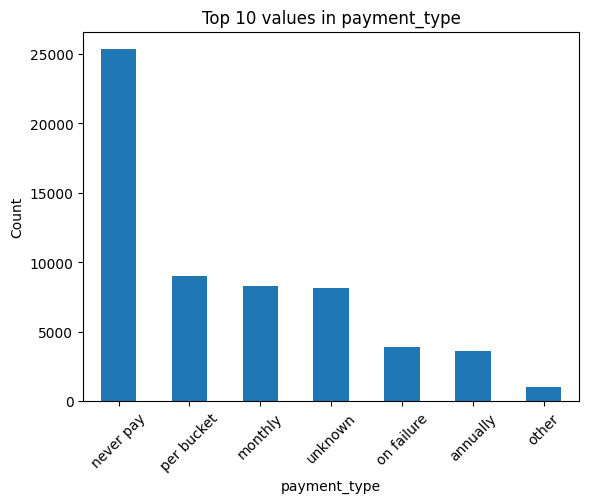

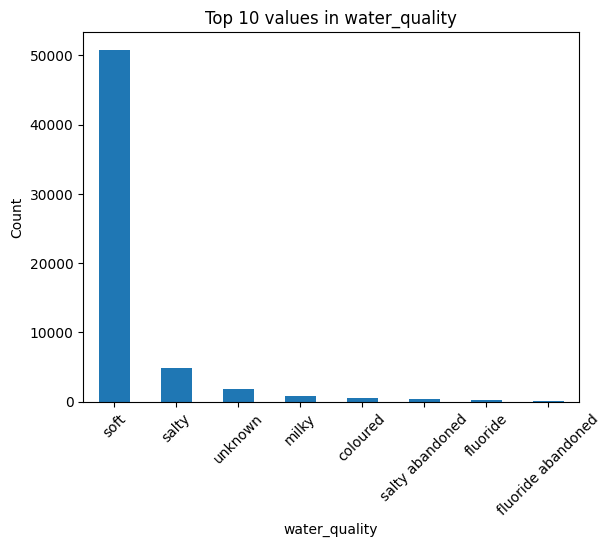

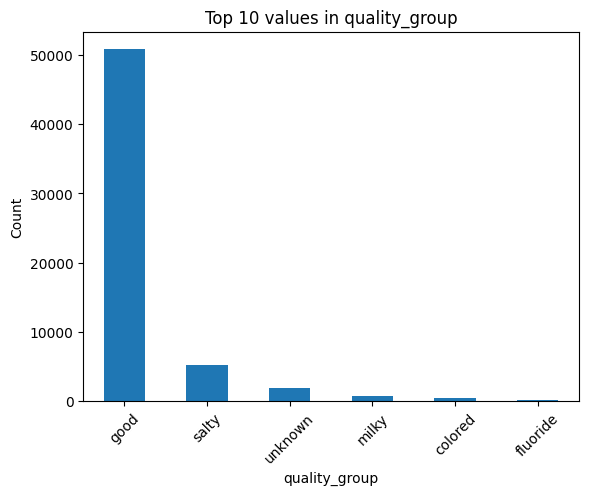

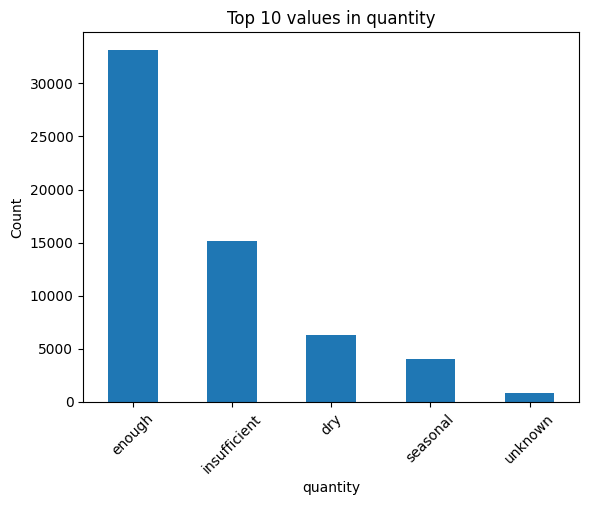

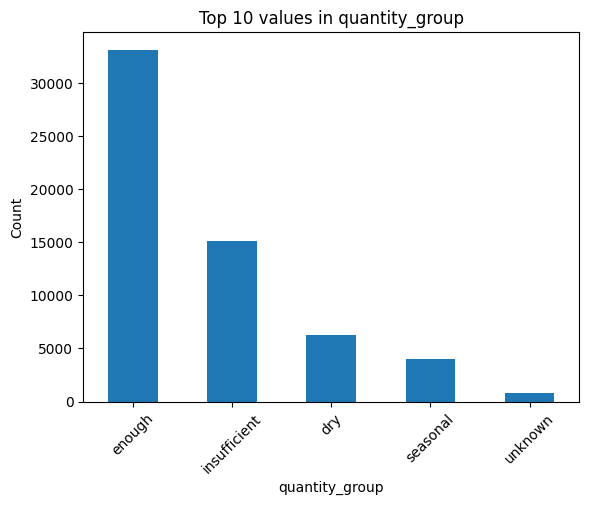

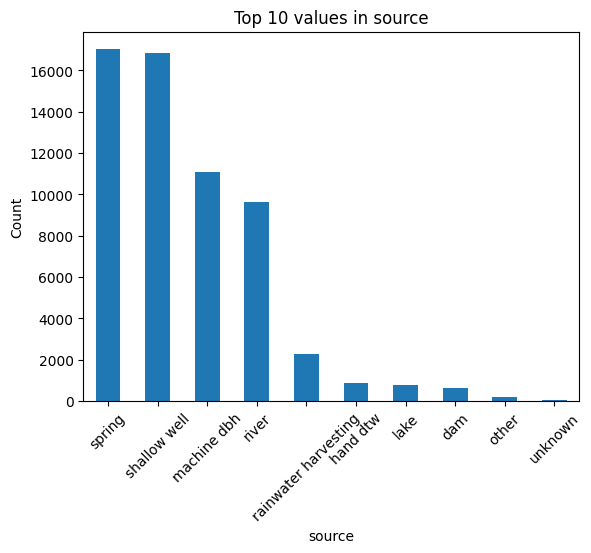

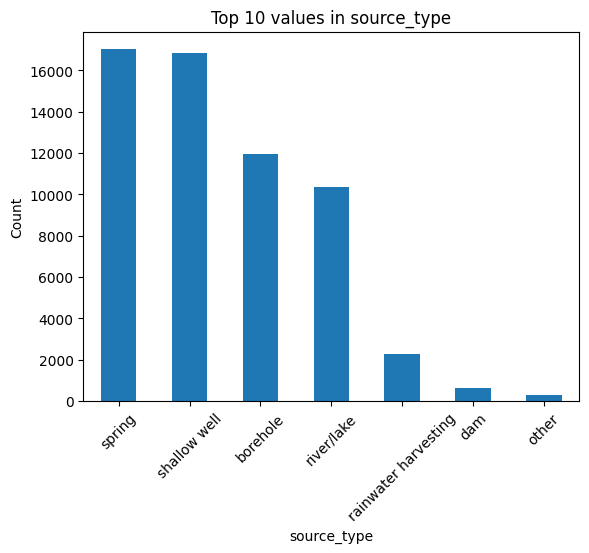

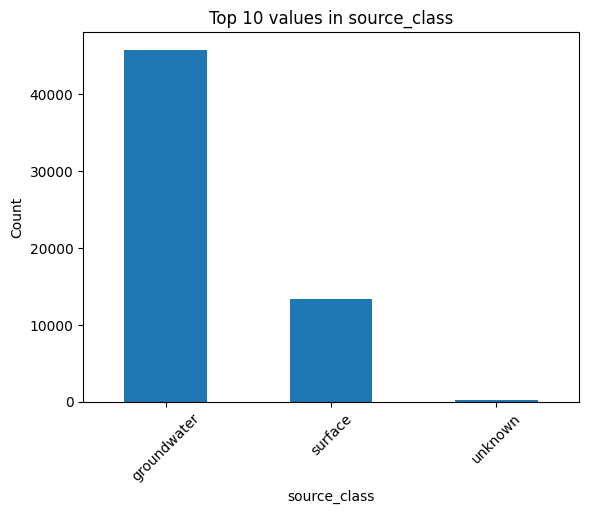

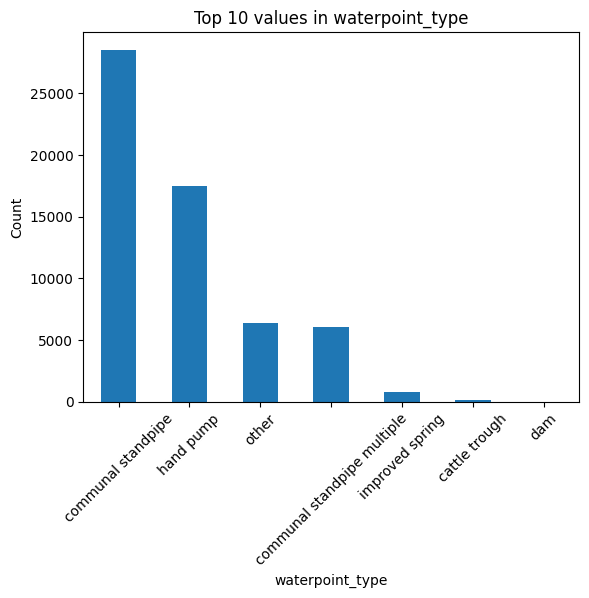

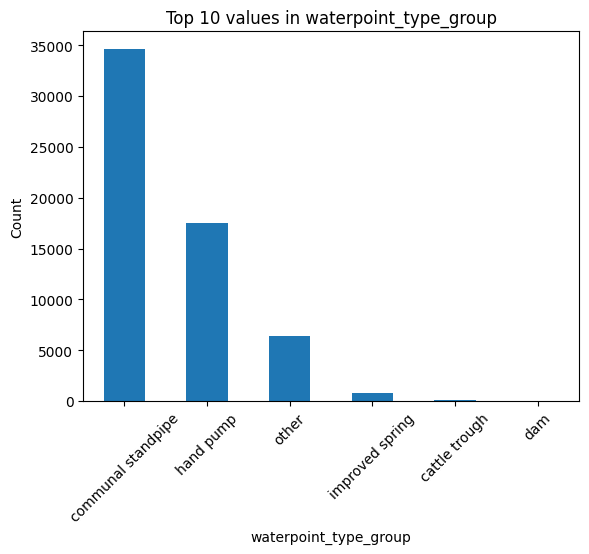

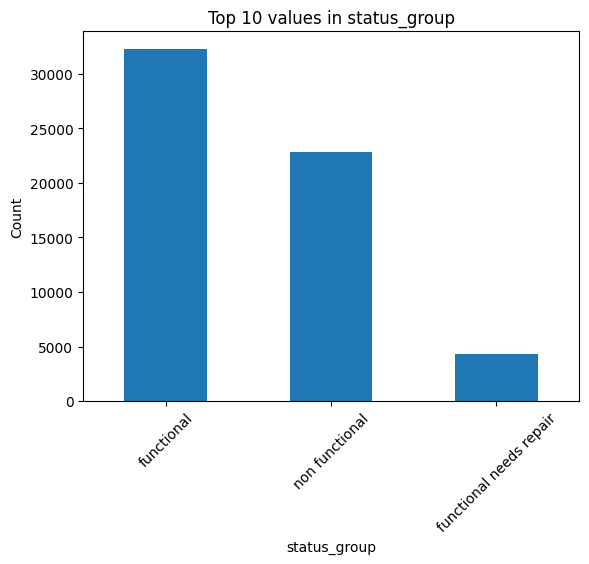

In [15]:
plot_categorical_counts(df_raw)


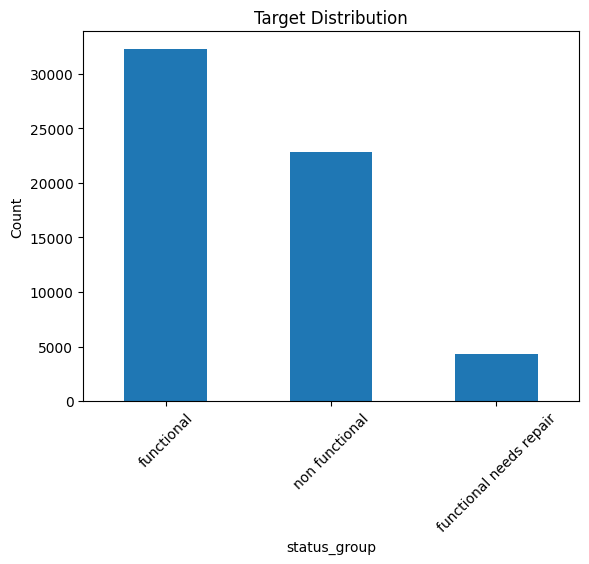

In [16]:
plot_target_distribution(df_raw, "status_group")


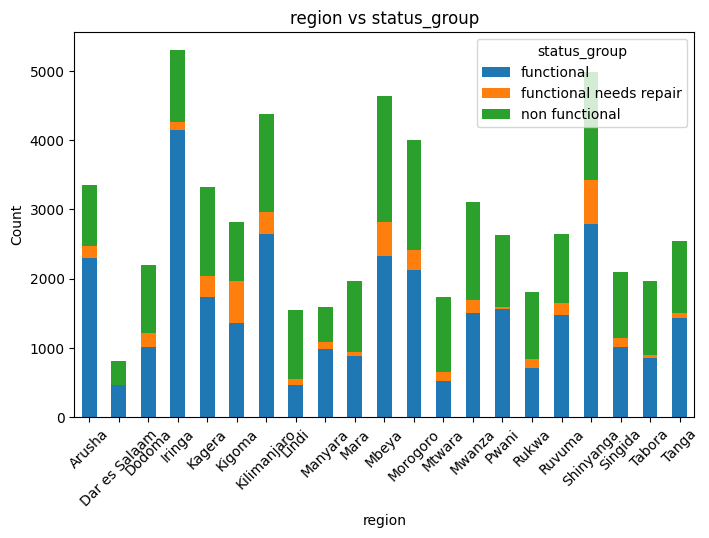

In [17]:
plot_feature_vs_target(df_raw, "region", "status_group")


In [18]:
outlier_overview(df_raw, exclude_cols=['region_code', 'district_code','id', 'latitude', 'longitude'])

 Simple Outlier Overview:
              column  outliers  percentage (%)  severity
0         amount_tsh     11161           18.79      High
4         population      4383            7.38  Moderate
3        num_private       757            1.27       Low
2         gps_height         0            0.00       Low
1  construction_year         0            0.00       Low


,column,outliers,percentage (%),severity
0,amount_tsh,11161,18.79,High
4,population,4383,7.38,Moderate
3,num_private,757,1.27,Low
2,gps_height,0,0.00,Low
1,construction_year,0,0.00,Low


# FINDINGS

Summary of what we learnt from the raw data and what we intend to do

# AFTER CLEANING

In [19]:
df_clean = load_data("../data/df_clean.csv")



DataFrame successfully loaded.
Shape: (58866, 31)
